In [92]:
import starsim as ss
import stisim as sti
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

# Part 1: Getting started

## Hello World

Initializing sim with 1000 agents
Figure(800x600)


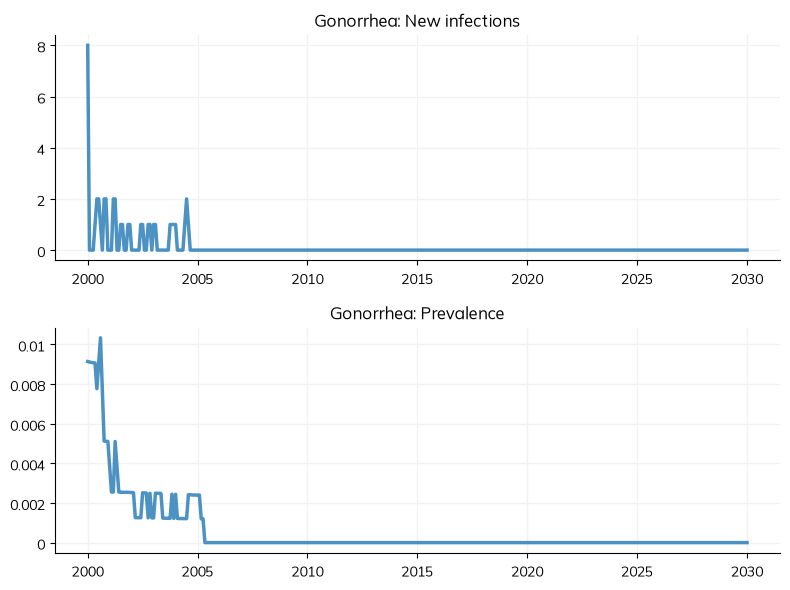

In [2]:
sim = sti.Sim(diseases='ng')
sim.run(verbose=0)
sim.plot(key=['ng.new_infections', 'ng.prevalence'])

## Inspect Simulation Parameters

In [5]:
## Inspect Simulation Parameters

sim = sti.Sim(diseases='ng')
sim.init()

print(f'Start:    {sim.pars.start}')
print(f'Stop:     {sim.pars.stop}')
print(f'Timestep: {sim.pars.dt} years ({sim.pars.dt*12:.0f} month)')
print(f'Agents:   {sim.pars.n_agents}')

Initializing sim with 1000 agents
Start:    2000
Stop:     2030
Timestep: 0.08333333333333333 years (1 month)
Agents:   1000


## Networks

In [6]:
for name, nw in sim.networks.items():
     print(f'{name}: {type(nw).__name__}')

structuredsexual: StructuredSexual
maternalnet: MaternalNet


## Disease

In [7]:
ng = sim.diseases.ng
print(f'Disease: {type(ng).__name__}')
print(f'Transmission (M to F): {ng.pars.beta_m2f}')
print(f'Initial prevalence: {ng.pars.init_prev}')
print(f'Condom efficacy: {ng.pars.eff_condom}')

Disease: Gonorrhea
Transmission (M to F): 0.06
Initial prevalence: ss.bernoulli(p=0.01)
Condom efficacy: 0.9


## Customizing the simulation

### Passing parameters inline

In [9]:
sim = sti.Sim(
    diseases='ng',
    n_agents=2000,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2010—2025; networks=structuredsexual, maternalnet; diseases=ng)

### Passing disease-specific parameters using sti_pars
Overwrites disease defaults without creating disease object myself

In [14]:
sti_pars=dict(
    ng=dict(init_prev=0.05),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases=['ng', 'ct'],
    sti_pars = sti_pars)

sim.run(verbose=0)

Initializing sim with 1000 agents


Sim(n=1000; 2000—2030; networks=structuredsexual, maternalnet; diseases=ng, ct)

## Exercises

### Exercise 1: 

Create a sim with both gonorrhea and chlamydia. Run it and plot the results.

Initializing sim with 2000 agents
Figure(800x600)


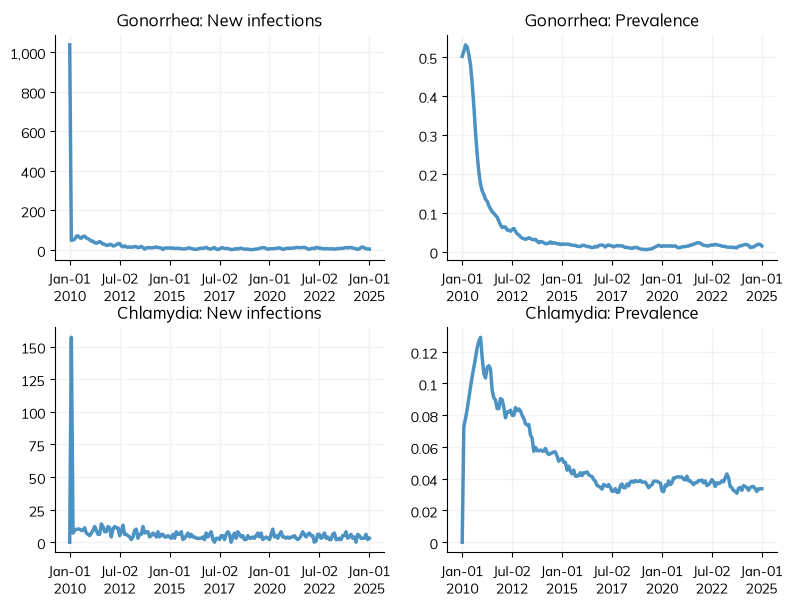

In [30]:
sti_pars=dict(
    ng=dict(init_prev=0.5),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases = ['ng', 'ct'],
    n_agents = 2000,
    sti_pars=sti_pars,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

sim.plot(key=['ng.new_infections', 'ng.prevalence', 'ct.new_infections', 'ct.prevalence'])

### Exercise 2: 

Try changing the gonorrhea transmission rate (beta_m2f) from 0.06 to 0.15 and observe how it affects prevalence.

Initializing sim with 2000 agents
Figure(800x600)


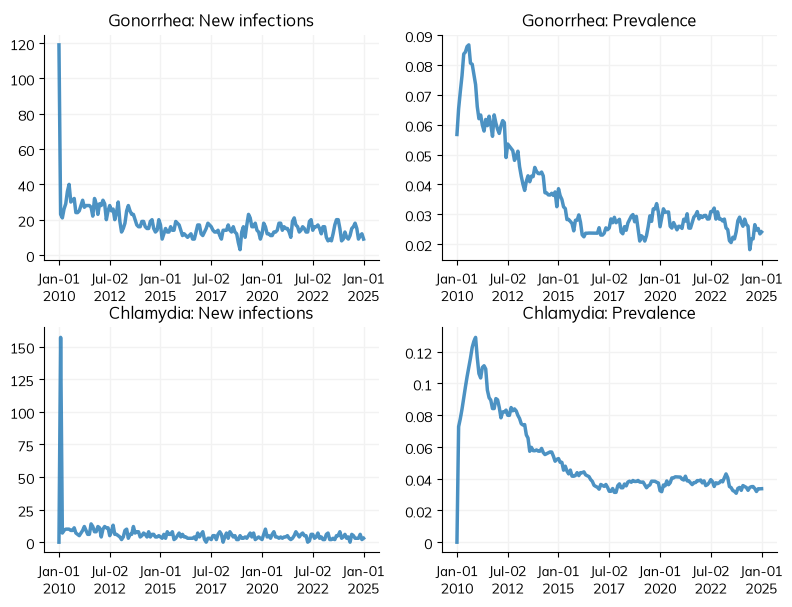

In [29]:
sti_pars=dict(
    ng=dict(init_prev=0.05, beta_m2f = 0.15),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases = ['ng', 'ct'],
    n_agents = 2000,
    sti_pars=sti_pars,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

sim.plot(key=['ng.new_infections', 'ng.prevalence', 'ct.new_infections', 'ct.prevalence'])

### Exercise 3: 

Add demographics by passing demographics='zimbabwe' and compare the results to the default (no demographics) sim.

In [ ]:
demographics = 'zimbabwe'

sti_pars=dict(
    ng=dict(init_prev=0.05, beta_m2f = 0.15),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases = ['ng', 'ct'],
    n_agents = 2000,
    sti_pars=sti_pars,
    demographics=demographics,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

sim.plot(key=['ng.new_infections', 'ng.prevalence', 'ct.new_infections', 'ct.prevalence'])

# Part 2: Results and Plotting

## Setup

Run a simple ng simulation to start:

In [33]:
sim = sti.Sim(diseases='ng', n_agents=2000, start=2010, stop=2030)
sim.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2010—2030; networks=structuredsexual, maternalnet; diseases=ng)

Available results are now stored in `sim.results`. Each disease has its own results object, accessible through `.keys()`

In [37]:
sim.results.ng.keys()[:5]

['timevec', 'n_susceptible', 'n_infected', 'n_exposed', 'n_asymptomatic']

In [38]:
# Access individual results
prev = sim.results.ng.prevalence
print(f'{prev.label}: min={prev.values.min():.3f}, mean={prev.values.mean():.3f}, max={prev.values.max():.3f}')

new_inf = sim.results.ng.new_infections
print(f'{new_inf.label}: min={new_inf.values.min():.0f}, mean={new_inf.values.mean():.1f}, max={new_inf.values.max():.0f}')

# There are many more -- including by sex and age group
print(f'\nTotal result keys: {len(sim.results.ng.keys())}')

Prevalence: min=0.000, mean=0.001, max=0.009
New infections: min=0, mean=0.2, max=16

Total result keys: 204


## Automatic plotting

Figure(933.333x700)


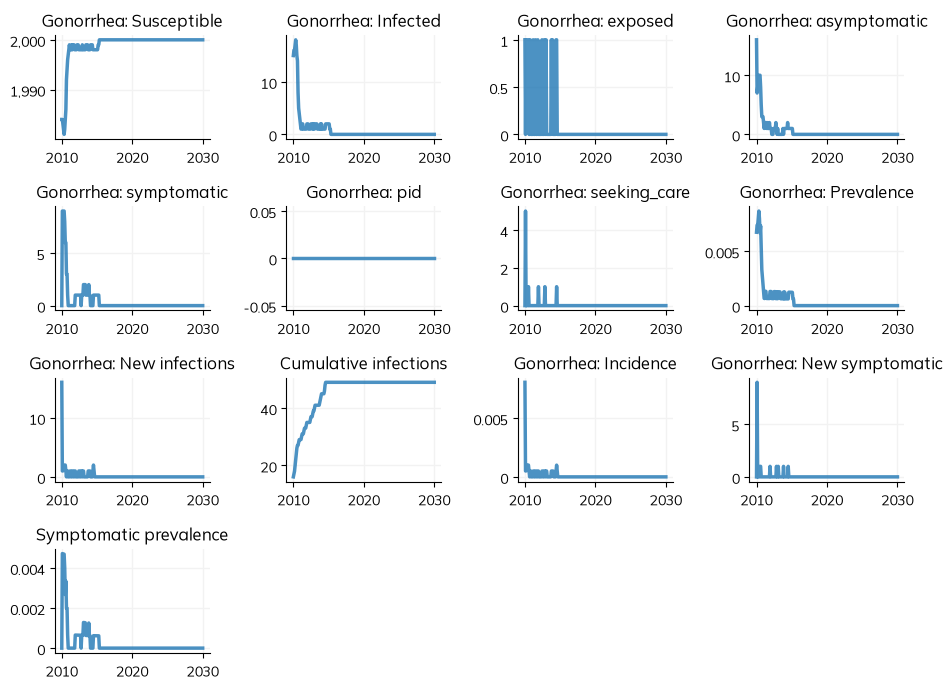

In [39]:
sim.plot()

## Plotting specific results

Figure(800x600)


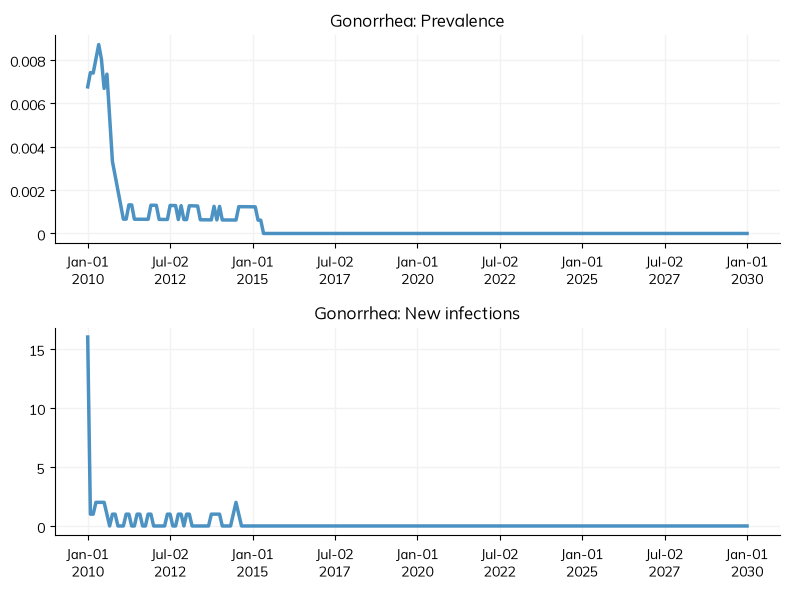

In [41]:
# Plot just prevalence and new infections
sim.plot(key=['ng.prevalence', 'ng.new_infections'])

## Exporting results as a dataframe

In [42]:
df = sim.to_df()
print(f'Shape: {df.shape}')
df.head()

Shape: (241, 211)


,timevec,structuredsexual_n_edges,maternalnet_n_edges,ng_n_susceptible,ng_n_infected,ng_n_exposed,ng_n_asymptomatic,ng_n_symptomatic,ng_n_pid,ng_n_seeking_care,...,ng_new_symptomatic_m_50_65,ng_symp_prevalence_m_50_65,ng_new_symptomatic_m_65_100,ng_symp_prevalence_m_65_100,ng_rel_treat,n_alive,n_female,new_deaths,new_emigrants,cum_deaths
0,2010-01-01,228.0,0.0,1984.0,15.0,1.0,16.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
1,2010-01-31,267.0,0.0,1984.0,16.0,0.0,7.0,9.0,0.0,5.0,...,1.0,0.005988,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
2,2010-03-03,365.0,0.0,1983.0,16.0,1.0,8.0,9.0,0.0,0.0,...,0.0,0.005952,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
3,2010-04-02,398.0,0.0,1982.0,17.0,1.0,9.0,9.0,0.0,1.0,...,0.0,0.005917,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
4,2010-05-03,398.0,0.0,1981.0,18.0,1.0,10.0,9.0,0.0,0.0,...,0.0,0.005780,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0


## Resampling to annual results
STIsim runs with monthly timesteps by default, but you’ll often want annual results for reporting or comparison with data. Use the resample() method on any result:

In [43]:
# Monthly new infections (raw)
monthly = sim.results.ng.new_infections
print(f'Monthly: {len(monthly.values)} timesteps')

# Resample to annual (sums monthly counts)
annual = monthly.resample('year')
print(f'Annual:  {len(annual)} years')
print(annual)

Monthly: 241 timesteps
Annual:  21 years
Result(Gonorrhea.new_infections: min=0, mean=2.33333, max=29)


## Plotting with Matplotlib

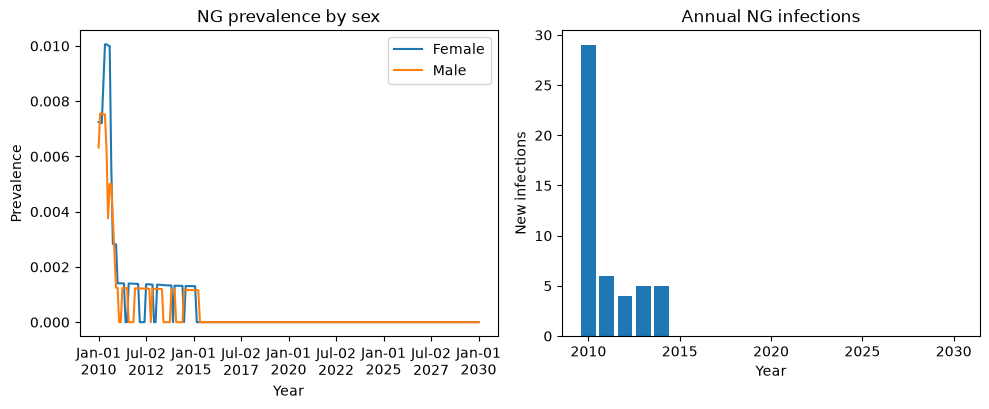

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: prevalence by sex
axes[0].plot(sim.timevec, sim.results.ng.prevalence_f, label='Female')
axes[0].plot(sim.timevec, sim.results.ng.prevalence_m, label='Male')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Prevalence')
axes[0].set_title('NG prevalence by sex')
axes[0].legend()

# Right: annual new infections (resampled)
annual_inf = sim.results.ng.new_infections.resample('year', use_years=True)
axes[1].bar(annual_inf.timevec, annual_inf.values)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('New infections')
axes[1].set_title('Annual NG infections')

plt.tight_layout()
fig

## Custom results

STISim's built-in results cover the most common quantities (prevalence, incidence, etc).

Also possible to define custom results: **analyzers, interventions, networks, connnectors, and diseases** all use the same `define_results` pattern.  The example below shows a custom analyzer which tracksng prevalence among people aged 15-24

In [48]:
class YouthPrev(ss.Analyzer):
    """Track gonorrhea prevalence among 15-24 year olds."""

    def init_pre(self, sim):
        super().init_pre(sim)
        # define_results registers a result with the sim's results system.
        # After sim.run(), it appears in sim.results.youthprev.ng_prev_15_24
        # and in sim.to_df() as 'youthprev.ng_prev_15_24'.
        self.define_results(
            ss.Result('ng_prev_15_24', dtype=float, scale=False, label='NG prev (15-24)'),
        )

    def step(self):
        ppl = self.sim.people
        youth = (ppl.age >= 15) & (ppl.age < 25)       # Boolean mask for 15-24 year olds
        n_youth = youth.count()                          # How many are in this group
        if n_youth > 0:
            infected = self.sim.diseases.ng.infected     # Boolean: who is infected
            prev = (infected & youth).count() / n_youth  # Prevalence = infected / total
            self.results['ng_prev_15_24'][self.ti] = prev

In [49]:
# Create the object
youth_prev = YouthPrev()
ng = sti.Gonorrhea(init_prev=ss.bernoulli(p=0.1))  # Higher init_prev so the demo has visible infections among youth

# With the simulation add the youth_prev analyzer to the list
sim = sti.Sim(diseases=ng, analyzers=youth_prev, n_agents=2000, start=2015, stop=2020)
sim.run(verbose=0)



Initializing sim with 2000 agents
Result(YouthPrev.ng_prev_15_24: min=0.00657895, mean=0.0337935, max=0.124183)


Figure(800x600)


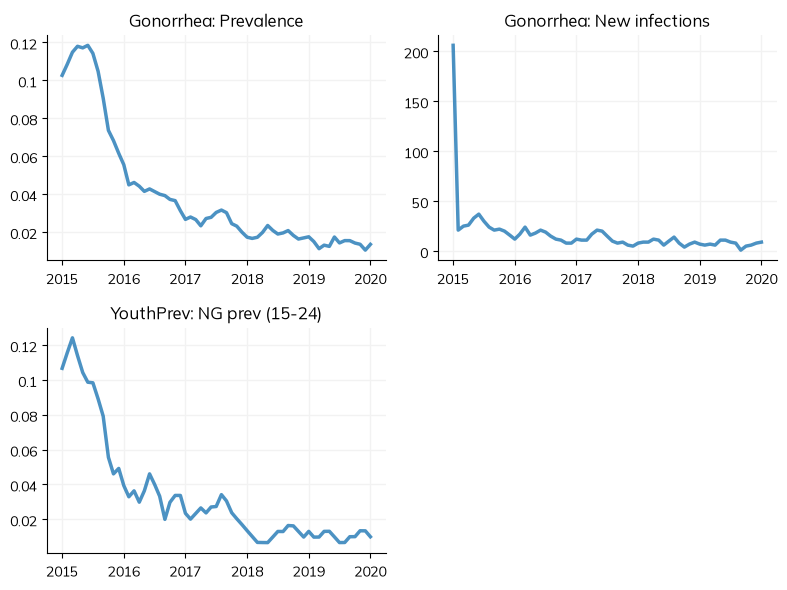

In [56]:
sim.plot(key=['ng.prevalence', 'ng.new_infections', 'youthprev.ng_prev_15_24'])

Figure(640x480)


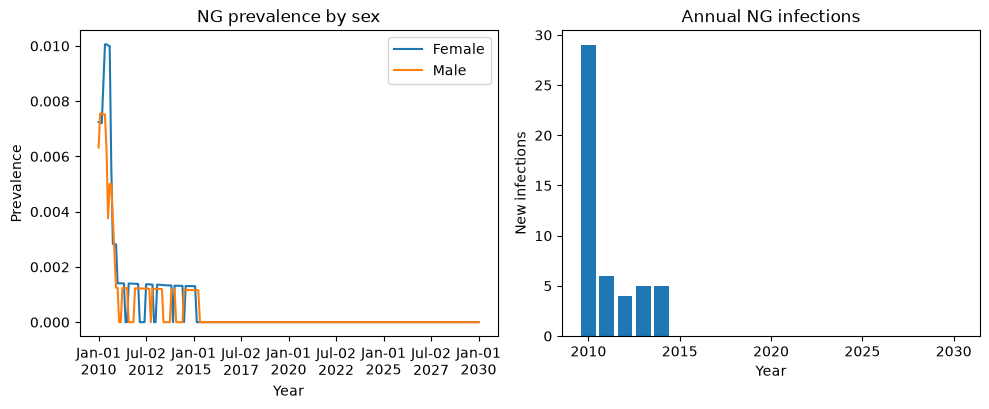

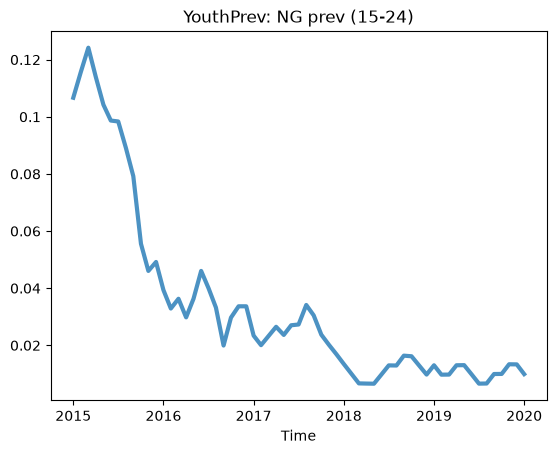

In [53]:
sim.results.youthprev.ng_prev_15_24.plot()

## Exercises

### Exercise 1

Run a sim with both 'ng' and 'ct'. Use sim.plot(key=...) to compare the prevalence of the two diseases on the same figure.

Initializing sim with 1000 agents
Figure(800x600)


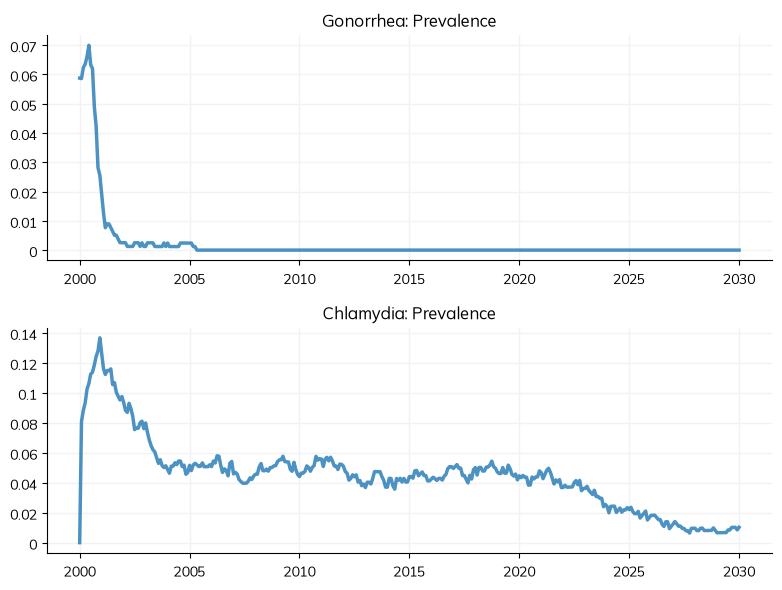

In [57]:
sti_pars=dict(
    ng=dict(init_prev=0.05),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases=['ng', 'ct'],
    sti_pars = sti_pars)

sim.run(verbose=0)

sim.plot(key=['ng.prevalence', 'ct.prevalence'])

### Exercise 2

Convert to a dataframe

In [59]:
df = sim.to_df()
print(f'Shape: {df.shape}')
df.head()

Shape: (361, 413)


,timevec,structuredsexual_n_edges,maternalnet_n_edges,ng_n_susceptible,ng_n_infected,ng_n_exposed,ng_n_asymptomatic,ng_n_symptomatic,ng_n_pid,ng_n_seeking_care,...,ct_symp_prevalence_m_35_50,ct_new_symptomatic_m_50_65,ct_symp_prevalence_m_50_65,ct_new_symptomatic_m_65_100,ct_symp_prevalence_m_65_100,n_alive,n_female,new_deaths,new_emigrants,cum_deaths
0,2000-01-01,121.0,0.0,943.0,57.0,0.0,57.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
1,2000-01-31,144.0,0.0,940.0,57.0,3.0,36.0,24.0,0.0,11.0,...,0.054264,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
2,2000-03-02,199.0,0.0,937.0,60.0,3.0,37.0,26.0,0.0,2.0,...,0.062016,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
3,2000-04-02,217.0,0.0,935.0,61.0,4.0,39.0,26.0,0.0,4.0,...,0.069231,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
4,2000-05-02,213.0,0.0,931.0,63.0,6.0,42.0,27.0,0.0,3.0,...,0.078125,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0


### Exercise 3

Plot monthly symptomatic prevalence and total prevalence

Figure(800x600)


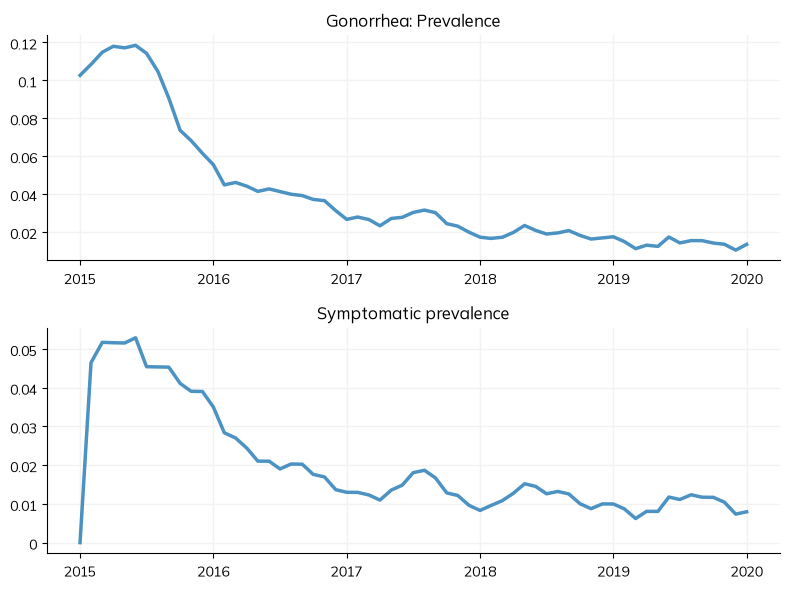

In [70]:
sim.plot(key=['ng.prevalence', 'ng.symp_prevalence'])

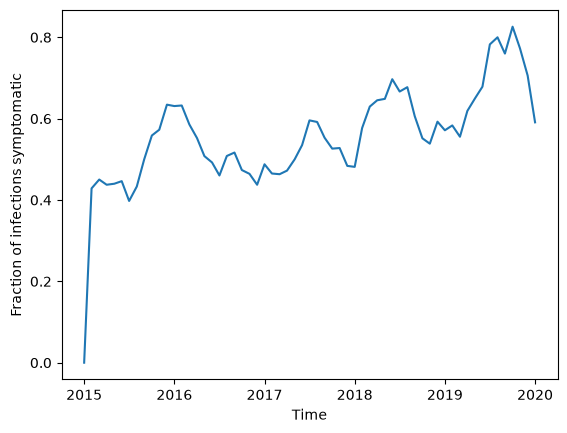

In [99]:
prev = sim.results.ng.prevalence.values
symp = sim.results.ng.symp_prevalence.values
frac = np.divide(symp, prev, out=np.full_like(prev, np.nan), where=(prev > 0))  # avoid 0/0

fig, ax = plt.subplots()
ax.plot(sim.results.ng.prevalence.timevec, frac)
ax.set_ylabel('Fraction of infections symptomatic')
ax.set_xlabel('Time')

plt.show()

### Exercise 4

Write an analyzer that tracks the number of symptomatic gonorrhea cases in males aged 25-49. Run the sim with it and verify the result appears in sim.to_df().

In [100]:
class AdultPrev(ss.Analyzer):
    """Track gonorrhea prevalence among 15-24 year olds."""

    def init_pre(self, sim):
        super().init_pre(sim)
        # define_results registers a result with the sim's results system.
        # After sim.run(), it appears in sim.results.youthprev.ng_prev_15_24
        # and in sim.to_df() as 'youthprev.ng_prev_15_24'.
        self.define_results(
            ss.Result('ng_prev_25_49', dtype=float, scale=False, label='NG prev (25-49)'),
        )

    def step(self):
        ppl = self.sim.people
        adults = (ppl.age >= 25) & (ppl.age < 50)       # Boolean mask for 15-24 year olds
        n_adults = adults.count()                          # How many are in this group
        if n_adults > 0:
            infected = self.sim.diseases.ng.infected     # Boolean: who is infected
            prev = (infected & adults).count() / n_adults  # Prevalence = infected / total
            self.results['ng_prev_25_49'][self.ti] = prev

In [65]:
# Create the object
adult_prev = AdultPrev()
ng = sti.Gonorrhea(init_prev=ss.bernoulli(p=0.1))  # Higher init_prev so the demo has visible infections among youth

# With the simulation add the youth_prev analyzer to the list
sim = sti.Sim(diseases=ng, analyzers=[youth_prev, adult_prev], n_agents=2000, start=2015, stop=2020)
sim.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2015—2020; networks=structuredsexual, maternalnet; diseases=ng; analyzers=youthprev, adultprev)

In [88]:
df = sim.to_df()

df.loc[:, ["timevec", "adultprev_ng_prev_25_49", "youthprev_ng_prev_15_24"]]

,timevec,adultprev_ng_prev_25_49,youthprev_ng_prev_15_24
0,2015-01-01,0.101896,0.106667
1,2015-01-31,0.108205,0.115512
2,2015-03-03,0.116806,0.124183
3,2015-04-02,0.127685,0.114007
4,2015-05-03,0.136691,0.104235
...,...,...,...
56,2019-09-01,0.026097,0.009967
57,2019-10-02,0.023725,0.010000
58,2019-11-01,0.021277,0.013378
59,2019-12-02,0.015366,0.013333


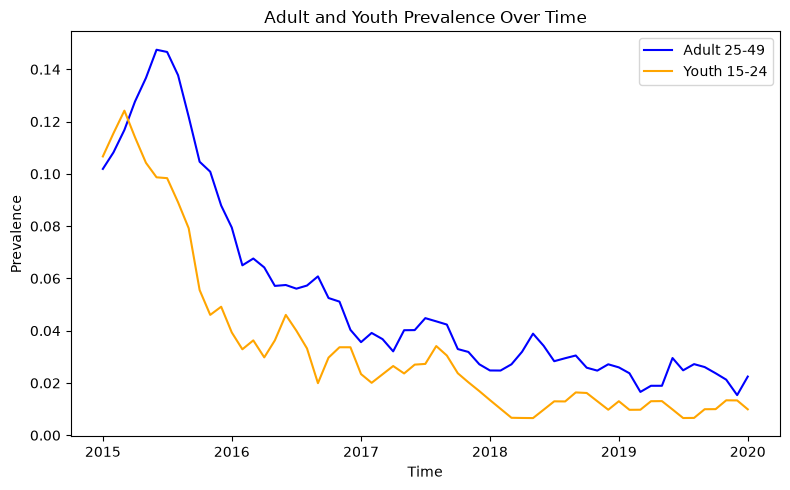

In [96]:
df["timevec"] = pd.to_datetime(df["timevec"])

plt.figure(figsize=(8, 5))
plt.plot(df["timevec"], df["adultprev_ng_prev_25_49"], label="Adult 25-49", color="blue")
plt.plot(df["timevec"], df["youthprev_ng_prev_15_24"], label="Youth 15-24", color="orange")

plt.xlabel("Time")
plt.ylabel("Prevalence")
plt.title("Adult and Youth Prevalence Over Time")
plt.legend()
plt.tight_layout()
plt.show()

# Part 3: Interventions